# Introduction

This is the source code for all of the experiments conducted in the paper titled: "Actions Have Consequences: Using Intervention Testing to Detect Outcome Performativity"

**Note:** Datasets used in the work are not included, you will need to download them from the links provided in the main paper.

The next two code blocks are prerequisite code that each set of experiments will need.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

def prepare_breast_cancer():
  return load_breast_cancer(return_X_y=True)


def prepare_diabetes():
  df = pd.read_csv("diabetes.csv")
  Y = df.pop('Outcome').to_numpy()
  X = df.to_numpy()
  return X, Y


def prepare_adult_census():
  df = pd.read_csv("adult.csv")
  Y = df.pop('income').to_numpy()
  Y = np.where(Y == '>50K', 1, 0)
  X = df[['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
         'hours.per.week']].to_numpy()
  return X, Y

def prepare_kickstarter():
  df = pd.read_csv("kickstarter.csv")
  Y = df.pop('final_status').to_numpy()
  X = df[['goal', 'backers_count']].to_numpy()
  return X, Y


def prepare_titanic():
  df = pd.read_csv("titanic.csv")
  Y = df.pop('Survived').to_numpy()
  X = df[['Age', 'SibSp', 'Parch', 'Fare', ]].to_numpy()
  isnan = ~np.isnan(X).any(axis=1)
  X = X[isnan]
  Y = Y[isnan]
  return X, Y

def prepare_loan():
  df = pd.read_csv("loan_approval_dataset.csv")
  Y = df.pop('loan_status').to_numpy()
  X = df.to_numpy()
  isnan = ~np.isnan(X).any(axis=1)
  X = X[isnan]
  Y = Y[isnan]
  return X, Y

# Simple Model Outcome Performativity

In [ ]:
rng = np.random.RandomState(42)  # deterministic random data

DATA_SAMPLES = [20, 200, 2000, 20000]  # can change to 20 200 2000 20000 for example
NAME = 'SIMPLE_MODEL'
REPETITIONS = 25
DELTA = 0.05

MIXES = np.linspace(0.0, 1.0, 100)
LABELS = np.linspace(0.0, 1.0, 11)

def extrema_labelling(yhat, mix, rng):
  inverse_labels = 1 - yhat
  filters = rng.uniform(size=yhat.shape)
  return np.where(filters < mix, yhat, inverse_labels)

def run_extrema_experiment(n, ms, rng, repetitions: int = 1):

  results = []

  for _ in range(repetitions):

    # Sample Distributions and Predictions
    # We can just generate N predictions here because
    # the simple model doesn't depend on X
    yhat_0 = np.zeros(n)
    yhat_1 = np.ones(n)

    # Label Datasets
    Y0 = extrema_labelling(yhat_0, ms[0], rng)
    Y1 = extrema_labelling(yhat_1, ms[1], rng)

    # Perform Statistical Test
    # Build Contingency Table
    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    # If one of the values is 0 we can't perform a Chi2 Test
    # so we use Fisher's Exact Test instead.
    if 0 in row1 or 0 in row2:
      res = stats.fisher_exact([row1, row2])
    else:
      res = stats.chi2_contingency([row1, row2], correction=False)

    results.append(1 if res.pvalue < DELTA else 0)

  return np.mean(results), np.std(results)

results = []

for samples in DATA_SAMPLES:
  pixels = []
  for m1 in MIXES:
    values = []
    for m0 in MIXES:
      # 1 - m0 will get us alpha_0 as defined in the paper
      values.append(run_extrema_experiment(samples // 2, [1 - m0, m1],
                                          rng, REPETITIONS)[0])
    pixels.append(np.array(values))
  results.append(pixels)

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 4)
fig.set_size_inches(20, 4)
locator = MaxNLocator(3)

ticks = range(len(MIXES))
xlabels = np.round(MIXES, 1)
ylabels = np.flip(xlabels)

for i in range(4):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), aspect="auto")

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor", fontsize=18)
  ax[i].set_yticks(ticks, labels=ylabels, fontsize=18)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(f"$N={DATA_SAMPLES[i] // 2}$", fontsize=20)

  ax[i].set_xlabel("$\\alpha_0$", fontsize=20)
  if i == 0:
    ax[i].set_ylabel("$\\alpha_1$", fontsize=20)

cbar = fig.colorbar(im, ax=ax.ravel().tolist())
cbar.ax.set_ylabel('Detection Rate', fontsize=20)
cbar.ax.tick_params(labelsize=18)

plt.savefig(f'{NAME}.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Adam Model Outcome Performativity

In [ ]:
rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 100
NUM_SAMPLES = 0.1  # Number of Instances to randomly sample for OP-AB
NAME = 'ADAM_MODEL'
LOAD_FUNCS = [prepare_breast_cancer, prepare_diabetes, prepare_adult_census, prepare_kickstarter, prepare_titanic, prepare_loan]
DATASETS = ['Breast Cancer', 'Diabetes', 'Adult Census', 'Kickstarter', 'Titanic', 'Loan']
DATASETS_SAMPLE_SIZE = []
GAMMAS = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def determine_new_labels_adam(Y, Y_hat, gamma):
    Y_new = np.copy(Y)

    # This is the mask applied in the Adam et al. paper
    #mask = (Y_hat == 1) & (Y == 0) & (rng.binomial(n=1, p=gamma, size=Y.shape) == 1)

    # This doesn't check for specific types of misclassifications
    # Which makes it more generalized.
    mask = (Y_hat != Y) & (rng.binomial(n=1, p=gamma, size=Y.shape) == 0)

    Y_new[mask] = 1 - Y_new[mask]  # Change desired outcomes
    return Y_new


def run_experiment(Y, gammas, num_samples: int, repetitions: int = 1):

  values = []
  for _ in range(repetitions):
    # AB Test Group Assignment
    Y_choice = rng.choice(Y, num_samples)
    Y_pred = rng.choice([0, 1], num_samples)
    Y0 = determine_new_labels_adam(Y_choice[Y_pred == 0], Y_pred[Y_pred == 0], gammas[0])
    Y1 = determine_new_labels_adam(Y_choice[Y_pred == 1], Y_pred[Y_pred == 1], gammas[1])

    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    values.append(1 if stats.chi2_contingency([row1, row2], correction=False).pvalue < 0.05 else 0)

  return np.mean(values), np.std(values)


results = []
for data_func in LOAD_FUNCS:

  _, Y = data_func()
  samples = 2 * int((NUM_SAMPLES * len(Y)) // 2)
  DATASETS_SAMPLE_SIZE.append(samples // 2)

  pixels = []
  for g1 in GAMMAS:
    values = []
    for g0 in GAMMAS:
      values.append(run_experiment(Y, [g0, g1], samples,
                                  repetitions=REPETITIONS)[0])
    pixels.append(values)

  results.append(np.array(pixels))

In [ ]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(1, 6)
fig.set_size_inches(30, 4)
locator = MaxNLocator(3)

ticks = range(len(GAMMAS))
xlabels = np.round(GAMMAS, 1)
ylabels = np.flip(xlabels)

for i in range(4):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), cmap='inferno', aspect="auto")

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor", fontsize=18)
  ax[i].set_yticks(ticks, labels=ylabels, fontsize=18)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(f"{DATASETS[i]} ($N={DATASETS_SAMPLE_SIZE[i]}$)", fontsize=18)
  ax[i].set_xlabel("$\\gamma_0$", fontsize=20)
  if i == 0:
    ax[i].set_ylabel("$\\gamma_1$", fontsize=20)

cbar = fig.colorbar(im, ax=ax.ravel().tolist())
cbar.ax.set_ylabel('Detection Rate', fontsize=20)
cbar.ax.tick_params(labelsize=18)

plt.savefig(f'{NAME}.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Feature-Dependent Outcome Performativity

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 100
NUM_SAMPLES = 0.1  # Number of Instances to randomly sample for OP-AB
NAME = 'FEATURE_DEPENDENT'
LOAD_FUNCS = [prepare_breast_cancer, prepare_diabetes, prepare_adult_census, prepare_kickstarter, prepare_titanic, prepare_loan]
DATASETS = ['Breast Cancer', 'Diabetes', 'Adult Census', 'Kickstarter', 'Titanic', 'Loan']
DATASETS_SAMPLE_SIZE = []
ALPHAS = np.array([-1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                   0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def determine_new_labels(X, model, coef, alpha):
    X_new = np.copy(X) + coef * alpha
    return model.predict(X_new)

def run_experiment(data, model, alphas: float, num_samples: int, repetitions: int = 1):

  coef = model.coef_  # Get Theta
  values = []

  for _ in range(repetitions):

    # Get samples
    samples = np.copy(data)
    rng.shuffle(samples)
    samples = samples[0:num_samples]

    # Split into X, Y
    X = samples[:, :-1]
    Y = samples[:, -1]

    Y_pred = rng.choice([0, 1], num_samples)

    Y0 = determine_new_labels(X[Y_pred == 0], model, coef, alphas[0])
    Y1 = determine_new_labels(X[Y_pred == 1], model, coef, alphas[1])

    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    # If one of the values is 0 we can't perform a Chi2 Test
    # so we use Fisher's Exact Test instead.
    if 0 in row1 or 0 in row2:
      res = stats.fisher_exact([row1, row2])
    else:
      res = stats.chi2_contingency([row1, row2], correction=False)

    values.append(1 if res.pvalue < 0.05 else 0)

  return np.mean(values), np.std(values)


results = []
for data_func in LOAD_FUNCS:

  X, Y = data_func()
  samples = 2 * int((NUM_SAMPLES * len(Y)) // 2)
  DATASETS_SAMPLE_SIZE.append(samples // 2)

  X = StandardScaler().fit_transform(X)

  base_model = LogisticRegression().fit(X, Y)  # Train f_theta
  data = np.append(X, Y.reshape(-1, 1), axis=1)

  pixels = []
  for a1 in ALPHAS:
    values = []
    for a0 in ALPHAS:
      values.append(run_experiment(data, base_model, [a0, a1],
                                  samples, repetitions=REPETITIONS)[0])
    pixels.append(np.array(values))

  results.append(np.array(pixels))

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 4)
fig.set_size_inches(30, 4)
locator = MaxNLocator(5)

ticks = range(len(ALPHAS))
xlabels = np.round(ALPHAS, 1)
ylabels = np.flip(xlabels)

for i in range(4):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), cmap='plasma', aspect="auto")

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor", fontsize=18)
  ax[i].set_yticks(ticks, labels=ylabels, fontsize=18)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(f"{DATASETS[i]} ($N={DATASETS_SAMPLE_SIZE[i]}$)", fontsize=18)
  ax[i].set_xlabel("$\\beta_0$", fontsize=20)
  if i == 0:
    ax[i].set_ylabel("$\\beta_1$", fontsize=20)

fig.subplots_adjust(wspace=0.2),

cbar = fig.colorbar(im, ax=ax.ravel().tolist())
cbar.ax.set_ylabel('Detection Rate', fontsize=20)
cbar.ax.tick_params(labelsize=18)

plt.savefig(f'{NAME}.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Open Bandit Dataset

You must first download the Open Bandit Dataset from: https://research.zozo.com/data.html

Here we use the Random sampling datasets.

In [ ]:
def prepare_OBD(name : str):
  df = pd.read_csv(name)
  Y = df.pop('click').to_numpy()
  X = df['position'].to_numpy()

  # Remove LEFT intervention
  filter = X != 2
  X = X[filter]
  Y = Y[filter]

  # Convert all interventions that put an Item LEFT to 1, otherwise 0
  X = np.where(X == 1, 1, 0)
  return X, Y

def prepare_filtered_OBD(name : str):
  df = pd.read_csv(name)
  Y = df.pop('click').to_numpy()
  X = df[['item_id', 'position']]

  # Remove LEFT intervention
  filter = X['position'] != 2
  X = X[filter]
  Y = Y[filter]

  # Convert all interventions that put an Item LEFT to 1, otherwise 0
  X['position'] = np.where(X['position'] == 1, 1, 0)

  X0 = X[Y == 0]
  X1 = X[Y == 1]

  _, x0_ind, x1_ind = np.intersect1d(X0['item_id'], X1['item_id'], return_indices=True)

  X0 = X0['position'].to_numpy()[x0_ind]
  X1 = X1['position'].to_numpy()[x1_ind]

  X = np.append(X0, X1)
  Y = np.append(np.zeros(len(X0)), np.ones(len(X1)))

  return X, Y

def prepare_OBD_women():
  return prepare_OBD('women.csv')

def prepare_OBD_men():
  return prepare_OBD('men.csv')

def prepare_OBD_all():
  return prepare_OBD('all.csv')


## Tests Using All Instances:

i.e. getting the label to see wether OP-AB should return `True` or `False`



In [ ]:
from scipy.stats.contingency import association
LOAD_FUNCS = [prepare_OBD_women, prepare_OBD_men]
DATASETS = ['women', 'men']

for i, d in enumerate(LOAD_FUNCS):
  X , Y = d()
  print(f"Dataset: {DATASETS[i]}")
  print(f'Samples: {len(X)}')

  Y0 = Y[X==0]
  Y1 = Y[X==1]

  row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
  row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

  print('Contingency Table:')
  print(f'{row1[0]} {row1[1]}')
  print(f'{row2[0]} {row2[1]}')

  res = stats.chi2_contingency([row1, row2], correction=False)
  print(f'Result: {res.pvalue}')
  print(f'Phi Coeff: {association([row1, row2])}')
  print()


Dataset: women
Samples: 576345
Contingency Table:
286807 286745
1401 1392
Result: 0.869585609843252
Phi Coeff: 0.0002162678057686505

Dataset: men
Samples: 301941
Contingency Table:
150288 150124
717 812
Result: 0.014499279197520386
Phi Coeff: 0.004448930663243094



## Downsampled OBD

In [ ]:
rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 1000
NUM_SAMPLES = [20, 200, 2000, 20000, 200000]
LOAD_FUNCS = [prepare_OBD_women, prepare_OBD_men]
DATASETS = ['women', 'men']


def run_experiment(data, num_samples: int, repetitions: int = 1):

  values = []
  for _ in range(repetitions):

    # Get samples
    samples = np.copy(data)
    rng.shuffle(samples)
    samples = samples[0:num_samples]

    # Split into X, Y
    X = samples[:, 0]
    Y = samples[:, -1]

    # Split by Intervention
    Y0 = Y[X==0]
    Y1 = Y[X==1]

    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    # If one of the values is 0 we can't perform a Chi2 Test
    # so we use Fisher's Exact Test instead.
    if 0 in row1 or 0 in row2:
      res = stats.fisher_exact([row1, row2])
    else:
      res = stats.chi2_contingency([row1, row2], correction=False)

    values.append(1 if res.pvalue < 0.05 else 0)

  return np.mean(values), np.std(values)


results = []
for data_func in LOAD_FUNCS:

  X, Y = data_func()
  data = np.append(X.reshape(-1, 1), Y.reshape(-1, 1), axis=1)

  values = []
  for num_samples in NUM_SAMPLES:
    values.append(run_experiment(data, num_samples, repetitions=REPETITIONS))

  results.append(values)

In [ ]:
print('Results:')
for i, x in enumerate(results):
  print(f'Dataset: {DATASETS[i]}')
  for j, res in enumerate(x):
      print(f'{NUM_SAMPLES[j]} : {res[0]}')

Results:
Dataset: women
20 : 0.0
200 : 0.001
2000 : 0.042
20000 : 0.041
200000 : 0.016
Dataset: men
20 : 0.0
200 : 0.0
2000 : 0.05
20000 : 0.094
200000 : 0.523


## Balanced OBD

In [ ]:
rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 1000
NUM_SAMPLES = [20, 100, 200, 1000, 2000]
LOAD_FUNCS = [prepare_OBD_women, prepare_OBD_men]
DATASETS = ['women', 'men']

def balance(data):
  filter = data[:, -1] == 1
  class1 = data[filter]
  class0 = data[~filter]

  rng.shuffle(class0)

  return np.append(class1, class0[0:len(class1)], axis=0)

def run_experiment(data, num_samples: int, repetitions: int = 1):

  values = []
  for _ in range(repetitions):

    # Get samples
    samples = np.copy(data)

    # Balance
    samples = balance(samples)

    rng.shuffle(samples)
    samples = samples[0:num_samples]

    # Split into X, Y
    X = samples[:, 0]
    Y = samples[:, -1]

    # Split by Intervention
    Y0 = Y[X==0]
    Y1 = Y[X==1]

    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    # If one of the values is 0 we can't perform a Chi2 Test
    # so we use Fisher's Exact Test instead.
    if 0 in row1 or 0 in row2:
      res = stats.fisher_exact([row1, row2])
    else:
      res = stats.chi2_contingency([row1, row2], correction=False)

    values.append(1 if res.pvalue < 0.05 else 0)

  return np.mean(values), np.std(values)


results = []
for data_func in LOAD_FUNCS:

  X, Y = data_func()
  data = np.append(X.reshape(-1, 1), Y.reshape(-1, 1), axis=1)

  values = []
  for num_samples in NUM_SAMPLES:
    values.append(run_experiment(data, num_samples, repetitions=REPETITIONS))

  results.append(values)

In [ ]:
print('Results:')
for i, x in enumerate(results):
  print(f'Dataset: {DATASETS[i]}')
  for j, res in enumerate(x):
      print(f'{NUM_SAMPLES[j]} : {res[0]}')

Results:
Dataset: women
20 : 0.046
100 : 0.059
200 : 0.06
1000 : 0.051
2000 : 0.032
Dataset: men
20 : 0.044
100 : 0.068
200 : 0.074
1000 : 0.159
2000 : 0.234


# Adam Detection

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 25
DIVISIONS = 11
GAMMAS = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def calc_TPR(Y, Y_pred):
  P = Y == 1
  TP = len(Y[(Y_pred == Y) & P])
  return TP / len(Y[P])

def calc_TNR(Y, Y_pred):
  N = Y == 0
  TN = len(Y[(Y_pred == Y) & N])
  return TN / len(Y[N])

def lo_hi_val(i : int, batch_size: int):
  return i * batch_size, (i+1) * (batch_size)

def determine_new_labels_adam(Y, Y_hat, gamma):
    Y_new = np.copy(Y)

    # This is the mask applied in the Adam et al. paper
    #mask = (Y_hat == 1) & (Y == 0) & (rng.binomial(n=1, p=gamma, size=Y.shape) == 1)

    # This doesn't check for specific types of misclassifications
    mask = (Y_hat != Y) & (rng.binomial(n=1, p=gamma, size=Y.shape) == 0)

    Y_change = Y_new[mask]
    Y_new[mask] = 1 - Y_new[mask]
    return Y_new

def run_experiment(data, gammas: float, divisions: int, repetitions: int = 1):

  values = []
  for _ in range(repetitions):

    rng.shuffle(data)

    X = data[:, :-1]
    Y = data[:, -1]

    batch_size = len(Y) // divisions
    eval_lo, eval_hi = lo_hi_val(divisions - 1, batch_size)


    X_eval = X[eval_lo:eval_hi]
    Y_eval = Y[eval_lo:eval_hi]

    # Model
    model = SGDClassifier()
    TPR_pre, TNR_pre = [], []
    TPR_post, TNR_post = [], []
    for i in range(divisions - 1):
      lo, hi = lo_hi_val(i, batch_size)
      if i < divisions // 2:
        model.partial_fit(X[lo:hi], Y[lo:hi], classes=np.unique(Y))

        # Get Score pre_deployment
        pred = model.predict(X_eval)
        TPR_pre.append(
            calc_TPR(Y_eval, pred)
            )
        TNR_pre.append(
            calc_TNR(Y_eval, pred)
        )
      else:
        # Predict
        Y_pred = model.predict(X[lo:hi])

        # Relabel Incorrect
        Y_new = np.copy(Y[lo:hi])

        mask = Y_pred == 0
        if(len(Y_new[mask] > 0)):
          Y_new[mask] = determine_new_labels_adam(Y_new[mask], Y_pred[mask], gammas[0])

        mask = Y_pred == 1
        if(len(Y_new[mask] > 0)):
          Y_new[mask] = determine_new_labels_adam(Y_new[mask], Y_pred[mask], gammas[1])

        # Update Model
        model.partial_fit(X[lo:hi], Y_new)

        # Get Score post_training
        pred = model.predict(X_eval)
        TPR_post.append(
            calc_TPR(Y_eval, pred)
            )
        TNR_post.append(
            calc_TNR(Y_eval, pred)
        )
    P = stats.mannwhitneyu(TPR_pre, TPR_post).pvalue < 0.05
    N = stats.mannwhitneyu(TNR_pre, TNR_post).pvalue < 0.05
    values.append(1 if P or N else 0)

  return np.mean(values)

X, Y = prepare_kickstarter()  # The Dataset you want to use.
X = StandardScaler().fit_transform(X)
print(f"Each Batch is of size: {len(Y) // DIVISIONS}")

data = np.append(X, Y.reshape(-1, 1), axis=1)

pixels = []
for g1 in GAMMAS:
  values = []
  for g0 in GAMMAS:
    values.append(run_experiment(data, [g0, g1], DIVISIONS, repetitions=REPETITIONS))
  pixels.append(values)

Each Batch is of size: 9829


In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()
im = ax.imshow(np.flip(pixels, 0), cmap='inferno', aspect='auto')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(GAMMAS)), labels=np.round(GAMMAS, 1),
           rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(GAMMAS)), labels=np.flip(np.round(GAMMAS, 1)))

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Detection Rate')

locator = MaxNLocator(11)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Loop over data dimensions and create text annotations.
A_SIZE = len(GAMMAS)
for i in range(A_SIZE):
    for j in range(A_SIZE):
        val = np.round(pixels[A_SIZE - 1 - i][j], 2)
        text = ax.text(j, i, val, ha="center", va="center",
                       color="w" if val < 0.85 else "black")

ax.set_title(f"Breast Cancer Dataset")
ax.set_xlabel("$ \\gamma_0 $")
ax.set_ylabel("$ \\gamma_1 $")

plt.savefig(f'ADAM_DETECTION_Breast_Cancer.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Detection Rate with Other Statistical Tests

In [ ]:
rng = np.random.RandomState(42)  # deterministic random data

TESTS = ['chi', 'fisher', 'mannu']

DATA_SAMPLES = 100
REPETITIONS = 25

MIXES = np.linspace(0.0, 1.0, 100)
LABELS = np.linspace(0.0, 1.0, 11)

def extrema_labelling(yhat, mix, rng):
  inverse_labels = 1 - yhat
  filters = rng.uniform(size=yhat.shape)
  return np.where(filters < mix, yhat, inverse_labels)

def run_extrema_experiment(n, ms, rng, repetitions: int = 1, test: str = 'chi'):

  results = []

  for _ in range(repetitions):

    # Sample Distributions and Predictions
    yhat_0 = np.zeros(n)
    yhat_1 = np.ones(n)

    # Label Datasets
    Y0 = extrema_labelling(yhat_0, ms[0], rng)
    Y1 = extrema_labelling(yhat_1, ms[1], rng)

    Y0_l = len(Y0)
    Y1_l = len(Y1)

    # Perform Statistical Test
    if test != 'mannu':
      # Build Contingency Table
      row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
      row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

      if test == 'fisher' or 0 in row1 or 0 in row2:
        res = stats.fisher_exact([row1, row2])
      else:
        res = stats.chi2_contingency([row1, row2])
    else:
      res = stats.mannwhitneyu(Y0, Y1)

    results.append(1 if res.pvalue < 0.05 else 0)

  return np.mean(results), np.std(results)


results = []

for test in TESTS:
  pixels = []
  for m1 in MIXES:
    values = []
    for m0 in MIXES:
      values.append(run_extrema_experiment(DATA_SAMPLES // 2, [1 - m0, m1],
                                          rng, REPETITIONS, test)[0])
    pixels.append(values)
  results.append(np.array(pixels))

In [ ]:
from matplotlib.ticker import MaxNLocator

TEST_NAMES = ['Chi-Squared Test', "Fisher's Exact Test", "Mann-Whitney U test"]

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 4)
locator = MaxNLocator(11)

ticks = range(len(MIXES))
xlabels = np.round(MIXES, 1)
ylabels = np.flip(xlabels)

for i in range(3):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), aspect="auto")

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor")
  ax[i].set_yticks(ticks, labels=ylabels)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(TEST_NAMES[i])
  ax[i].set_xlabel("$\\alpha_0$")
  ax[i].set_ylabel("$\\alpha_1$")

cbar = fig.colorbar(im, ax=ax.ravel().tolist())
cbar.ax.set_ylabel('Detection Rate')

plt.savefig(f'STATS_TESTS_SIMPLE_MODEL.pdf', dpi=400, bbox_inches='tight')

plt.show()

#Increased N on Breast Cancer Dataset

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 100
NUM_SAMPLES = [0.1, 0.25, 0.5, 0.75]
NAME = 'N_SAMPLES_BREAST_CANCER'
DATASETS_SAMPLE_SIZE = []
ALPHAS = np.array([-1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                   0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def determine_new_labels(X, model, coef, alpha):
    X_new = np.copy(X) + coef * alpha
    return model.predict(X_new)

def run_experiment(data, model, alphas: float, num_samples: int, repetitions: int = 1):

  coef = model.coef_  # Get Theta
  values = []

  for _ in range(repetitions):

    # Get samples
    samples = np.copy(data)
    rng.shuffle(samples)
    samples = samples[0:num_samples]

    # Split into X, Y
    X = samples[:, :-1]
    Y = samples[:, -1]

    Y_pred = rng.choice([0, 1], num_samples)

    Y0 = determine_new_labels(X[Y_pred == 0], model, coef, alphas[0])
    Y1 = determine_new_labels(X[Y_pred == 1], model, coef, alphas[1])

    row1 = [len(Y0[Y0 == 0]), len(Y1[Y1 == 0])]
    row2 = [len(Y0[Y0 == 1]), len(Y1[Y1 == 1])]

    # If one of the values is 0 we can't perform a Chi2 Test
    # so we use Fisher's Exact Test instead.
    if 0 in row1 or 0 in row2:
      res = stats.fisher_exact([row1, row2])
    else:
      res = stats.chi2_contingency([row1, row2], correction=False)

    values.append(1 if res.pvalue < 0.05 else 0)

  return np.mean(values), np.std(values)


results = []
for num_samples in NUM_SAMPLES:

  X, Y = prepare_breast_cancer()
  samples = 2 * int((num_samples * len(Y)) // 2)
  DATASETS_SAMPLE_SIZE.append(samples // 2)

  X = StandardScaler().fit_transform(X)

  base_model = LogisticRegression().fit(X, Y)  # Train f_theta
  data = np.append(X, Y.reshape(-1, 1), axis=1)

  pixels = []
  for a1 in ALPHAS:
    values = []
    for a0 in ALPHAS:
      values.append(run_experiment(data, base_model, [a0, a1],
                                  samples, repetitions=REPETITIONS)[0])
    pixels.append(np.array(values))

  results.append(np.array(pixels))

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 4)
fig.set_size_inches(25, 4)
locator = MaxNLocator(11)

ticks = range(len(ALPHAS))
xlabels = np.round(ALPHAS, 1)
ylabels = np.flip(xlabels)

for i in range(4):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), cmap='plasma', aspect="auto")

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor")
  ax[i].set_yticks(ticks, labels=ylabels)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(f"Breast Cancer ($N={DATASETS_SAMPLE_SIZE[i]}$)")
  ax[i].set_xlabel("$\\beta_0$")
  ax[i].set_ylabel("$\\beta_1$")

fig.subplots_adjust(wspace=0.2),

cbar = fig.colorbar(im, ax=ax.ravel().tolist())
cbar.ax.set_ylabel('Detection Rate')

plt.savefig(f'{NAME}.pdf', dpi=400, bbox_inches='tight')

plt.show()

# N Visualizations with varying $P_0$

In [ ]:
CHI_THRESHOLD = 3.841
P0 = [0.01, 0.25, 0.5, 0.75, 0.99]

GAMMAS = np.linspace(0.0, 1.0, 100)
LABELS = np.linspace(0.0, 1.0, 11)

def calc_num_samples(chi_threshold, p0, g0, g1):

  top = chi_threshold * (g0 * p0 + g1*p0 - g1 - 1) * ((g0 * p0 + g1*p0 - g1 + 1))
  btm = 2 * (g0 * p0 - g1*p0 + g1 - 1)**2

  return -top / btm if btm != 0.0 else -1.0

results = []

for p0 in P0:
  pixels = []
  for m1 in GAMMAS:
    values = []
    for m0 in GAMMAS:
      values.append(calc_num_samples(CHI_THRESHOLD, p0, m0, m1))
    pixels.append(values)
  results.append(np.array(pixels))

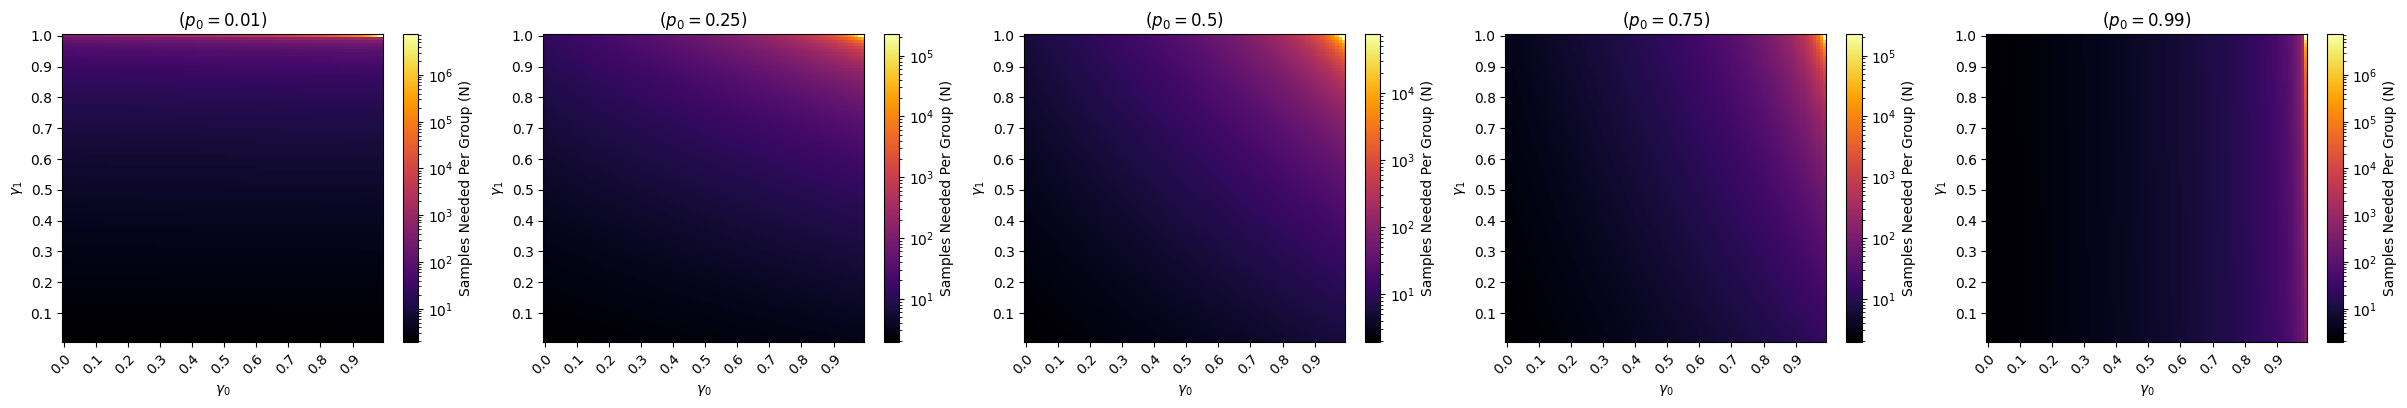

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 5)
fig.set_size_inches(30, 4)
locator = MaxNLocator(11)

ticks = range(len(GAMMAS))
xlabels = np.round(GAMMAS, 1)
ylabels = np.flip(xlabels)

for i in range(5):
  pixels = results[i]
  im = ax[i].imshow(np.flip(pixels, 0), cmap='inferno', aspect="auto", norm='log')

  # Show all ticks and label them with the respective list entries.
  ax[i].set_xticks(ticks, labels=xlabels,
            rotation=45, ha="right", rotation_mode="anchor")
  ax[i].set_yticks(ticks, labels=ylabels)

  ax[i].xaxis.set_major_locator(locator)
  ax[i].yaxis.set_major_locator(locator)

  ax[i].set_title(f"($p_0={P0[i]}$)")
  ax[i].set_xlabel("$\\gamma_0$")
  ax[i].set_ylabel("$\\gamma_1$")

  cbar = fig.colorbar(im, ax=ax[i])
  cbar.ax.set_ylabel('Samples Needed Per Group (N)')

plt.savefig(f'ADAM_MODEL_VIZ_P0.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Derivation of Estimated N for Adam Model Outcome Performativity:

In [ ]:
from sympy import *
N, p, g0, g1 = symbols('N p0 g0 g1')
init_printing(use_unicode=True)

#p = 0.5


# Average Oucomes
y0y0 = simplify(N * (p + (1 - p) * (1-g1)))
y0y1 = simplify(N * (1-p) * g1)

y1y0 = simplify(N * p * g0)
y1y1 = simplify(N * ((1-p) + p * (1 - g0)))

col0 = simplify(y0y0 + y0y1)
col1 = simplify(y1y0 + y1y1)

row0 = simplify(y0y0 + y1y0)
row1 = simplify(y0y1 + y1y1)

row1

total = simplify(col0 + col1)

# Expected Values

e00 = simplify((row0 * col0) / total)
e01 = simplify((row1 * col0) / total)
e10 = simplify((row0 * col1) / total)
e11 = simplify((row1 * col1) / total)

pairs = [(y0y0, e00), (y0y1, e01), (y1y0, e10), (y1y1, e11)]
total = 0

for o, e in pairs:
    total += simplify((((o - e) ** 2) / e))
    total = simplify(total)

total

# Derivation of Estimated N for Feature-Based Outcome Performativity:

In [ ]:
from sympy import *
N, b0, b1 = symbols('N b0 b1')
init_printing(use_unicode=True)

#b0 = 0.5
#b1 = 0.5

# Average Oucomes
y0y0 = N * (1 - b0)
y0y1 = N * b0

y1y0 = N * (1 - b1)
y1y1 = N * b1

col0 = N
col1 = N

row0 = y0y0 + y1y0
row1 = y0y1 + y1y1

total = 2*N

# Expected Values
e00 = simplify((row0 * col0) / total)
e01 = simplify((row1 * col0) / total)
e10 = simplify((row0 * col1) / total)
e11 = simplify((row1 * col1) / total)

pairs = [(y0y0, e00), (y0y1, e01), (y1y0, e10), (y1y1, e11)]
total = 0

for o, e in pairs:
    total += simplify((((o - e) ** 2) / e))
    total = simplify(total)

total

                 2     
   -2⋅N⋅(b₀ - b₁)      
───────────────────────
(b₀ + b₁)⋅(b₀ + b₁ - 2)

In [ ]:
CHI_THRESHOLD = 3.841

MIXES = np.linspace(0.0, 1.0, 100)
LABELS = np.linspace(0.0, 1.0, 11)

def calc_num_samples(chi_threshold, b0, b1):
  sum = b0 + b1
  diff = b0 - b1
  top = chi_threshold * (2*sum - sum*sum)
  btm = 2 * diff**2

  return top / btm if btm != 0.0 else -1.0

pixels = []
for m1 in MIXES:
  values = []
  for m0 in MIXES:
    values.append(calc_num_samples(CHI_THRESHOLD, m0, m1))
  pixels.append(values)

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

print(np.array(pixels).max())

im = ax.imshow(np.flip(pixels, 0), cmap='plasma', aspect='auto', norm='log')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(MIXES)), labels=np.round(MIXES, 1),
           rotation=45, ha="right", rotation_mode="anchor", fontsize=14)
ax.set_yticks(range(len(MIXES)), labels=np.flip(np.round(MIXES, 1)), fontsize=14)

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Samples Needed per Group (N)', fontsize=18)

locator = MaxNLocator(5)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

#ax.set_title(f"Estimated Number of Samples Needed to detect OP\nfor varying P(Y|Y')")
ax.set_xlabel("$p_{\\beta0}$",fontsize=20)
ax.set_ylabel("$p_{\\beta1}$", fontsize=20)

plt.savefig('N_threshold_feature.pdf', dpi=400, bbox_inches='tight')

plt.show()

## Estimating N using datasets

In [ ]:
CHI_THRESHOLD = 3.841

MIXES = np.linspace(0.0, 1.0, 100)
LABELS = np.linspace(0.0, 1.0, 11)

def calc_num_samples(chi_threshold, b0, b1):

  top = chi_threshold * (b0 + b1) * (b0 + b1 - 2)
  btm = 2 * (b0 - b1)**2

  return -top / btm if btm != 0.0 else -1.0

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

BETAS = np.linspace(-1.0, 1.0, 101) #np.array([-1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0,
                   #0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

def count_ones_proba(X, model, coef, beta):
    X_new = np.copy(X) + coef * beta
    preds = model.predict(X_new)
    return len(preds[preds == 1]) / len(preds)

def get_N(X, model, b0: float, b1: float, chi_threshold: float):
  coef = model.coef_  # Get Theta
  pb0 = count_ones_proba(X, model, coef, b0)
  pb1 = count_ones_proba(X, model, coef, b1)
  return calc_num_samples(chi_threshold, pb0, pb1)

X, Y = prepare_breast_cancer()

X = StandardScaler().fit_transform(X)

base_model = LogisticRegression().fit(X, Y)  # Train f_theta

pixels = []
for b1 in BETAS:
  values = []
  for b0 in BETAS:
    values.append(get_N(X, base_model, b0, b1, CHI_THRESHOLD))
  pixels.append(np.array(values))


In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

print(np.array(pixels).max())

im = ax.imshow(np.flip(pixels, 0), cmap='plasma', aspect='auto', norm='log')

ticks = range(len(BETAS))
xlabels = np.round(BETAS, 1)
ylabels = np.flip(xlabels)

# Show all ticks and label them with the respective list entries.
ax.set_xticks(ticks, labels=xlabels,
          rotation=45, ha="right", rotation_mode="anchor", fontsize=14)
ax.set_yticks(ticks, labels=ylabels, fontsize=14)

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Samples Needed per Group (N)', fontsize=14)
cbar.ax.tick_params(labelsize=14)

locator = MaxNLocator(5)

#ax.set_title('Breast Cancer', fontsize=16)
ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

#ax.set_title(f"Estimated Number of Samples Needed to detect OP\nfor varying P(Y|Y')")
ax.set_xlabel("$\\beta_0$", fontsize=16)
ax.set_ylabel("$\\beta_1$", fontsize=16)

plt.savefig('N_threshold_feature_breast_cancer.pdf', dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
N = 100

fig, ax = plt.subplots()

flipped = np.flip(pixels, 0)
filtered = np.where((flipped <= N) & (flipped > 0), 1.0, 0.0)

im = ax.imshow(filtered, cmap='plasma', aspect='auto') #norm='log')
# Show all ticks and label them with the respective list entries.
ax.set_xticks(ticks, labels=xlabels,
          rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(ticks, labels=ylabels)

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Detection Likelihood')

locator = MaxNLocator(11)

ax.set_title('Breast Cancer')
ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

#ax.set_title(f"Estimated Number of Samples Needed to detect OP\nfor varying P(Y|Y')")
ax.set_xlabel("$\\beta_0$")
ax.set_ylabel("$\\beta_1$")

plt.savefig('N_threshold_feature_breast_cancer_filtered.pdf', dpi=400)

plt.show()

# RCT Motivation Visualizations

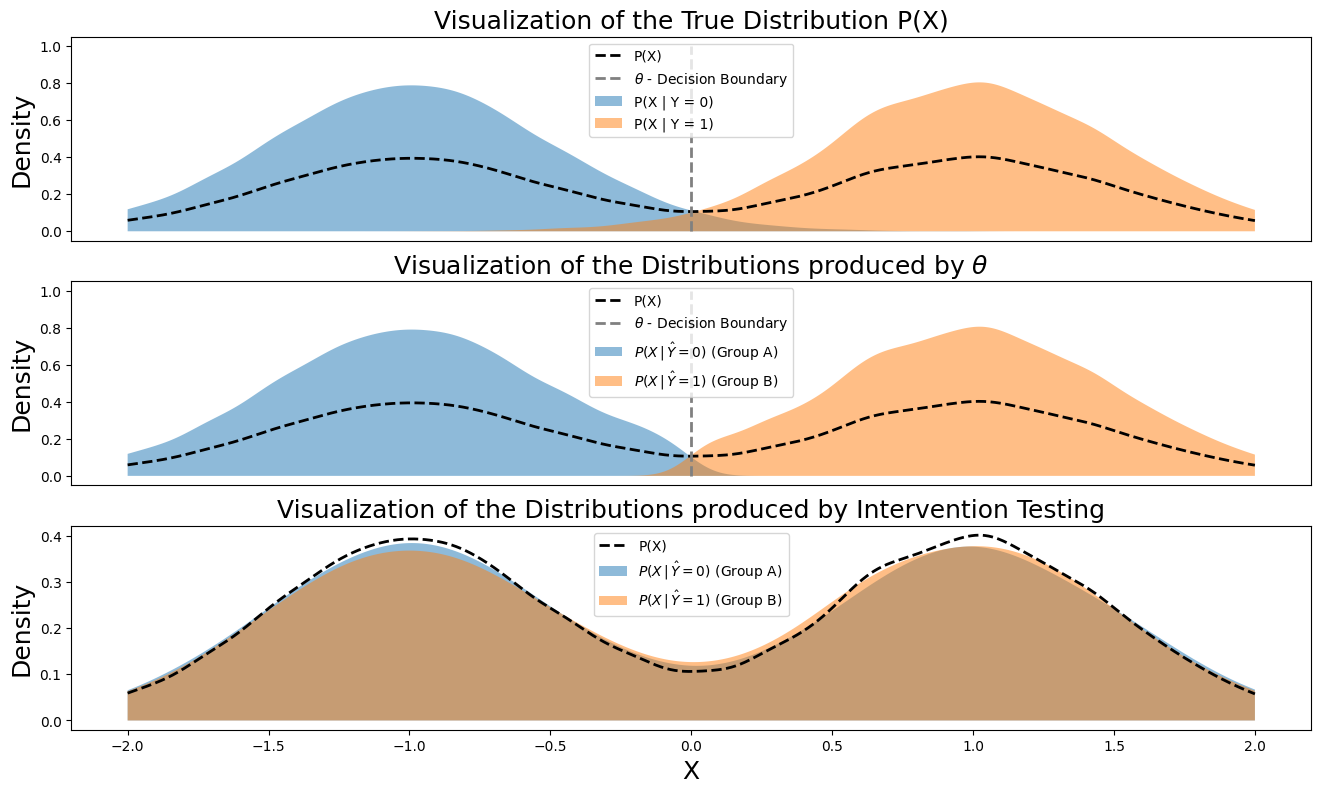

In [ ]:
rng = np.random.RandomState(42)

DATA_SAMPLES = 10000

u1, u2 = -1.0, 1.0
var = 0.5

dist1 = rng.normal(u1, var, DATA_SAMPLES)
dist2 = rng.normal(u2, var, DATA_SAMPLES)

NUM_QUERIES = 1000
x = np.linspace(-2.0, 2.0, NUM_QUERIES)

# plot the real distributions
kde1 = stats.gaussian_kde(dist1)
kde2 = stats.gaussian_kde(dist2)

px_y0, px_y1 = kde1.pdf(x), kde2.pdf(x)

# Assuming Equal probablity of getting class 1 and 0

px = (px_y0 + px_y1) * 0.5

fig, ax = plt.subplots(3, 1)
fig.set_size_inches(16, 9)

# First Row
ax[0].plot(x, px, lw=2, label='P(X)', color='black', linestyle='--')
ax[0].vlines(0.0, 0.0, 1.0, lw=2, label='$\\theta$ - Decision Boundary', color='gray', linestyle='--')
ax[0].fill_between(x, px_y0, alpha=0.5, label='P(X | Y = 0)')
ax[0].fill_between(x, px_y1, alpha=0.5, label='P(X | Y = 1)')
ax[0].set_title('Visualization of the True Distribution P(X)', fontsize=18)
#ax[0].set_xlabel("X")
ax[0].set_xticks([])
ax[0].set_ylabel("Density", fontsize=18)
ax[0].legend()

# Second Row
# plot the real KDE
mask1 = dist1 < 0.0
mask2 = dist2 < 0.0

kde1 = stats.gaussian_kde(np.concat((dist1[mask1], dist2[mask2])))
kde2 = stats.gaussian_kde(np.concat((dist1[~mask1], dist2[~mask2])))

px_yhat0, px_yhat1 = kde1.pdf(x), kde2.pdf(x)

ax[1].plot(x, px, lw=2, label='P(X)', color='black', linestyle='--')
ax[1].vlines(0.0, 0.0, 1.0, lw=2, label='$\\theta$ - Decision Boundary', color='gray', linestyle='--')
ax[1].fill_between(x, px_yhat0, alpha=0.5, label='$P(X \\, | \\, \\hat{Y} = 0)$ (Group A)')
ax[1].fill_between(x, px_yhat1, alpha=0.5, label='$P(X \\, | \\, \\hat{Y} = 1)$ (Group B)')
ax[1].set_title('Visualization of the Distributions produced by $\\theta$', fontsize=18)
#ax[1].set_xlabel("X")
ax[1].set_xticks([])
ax[1].set_ylabel("Density", fontsize=18)
ax[1].legend()

# Third Row
dist_cat = np.concat((dist1, dist2))

mask = rng.choice([0, 1], size = len(dist_cat)) == 0

kde1 = stats.gaussian_kde(dist_cat[mask])
kde2 = stats.gaussian_kde(dist_cat[~mask])

px_yhat0, px_yhat1 = kde1.pdf(x), kde2.pdf(x)

ax[2].plot(x, px, lw=2, label='P(X)', color='black', linestyle='--')
ax[2].fill_between(x, px_yhat0, alpha=0.5, label='$P(X \\, | \\, \\hat{Y} = 0)$ (Group A)')
ax[2].fill_between(x, px_yhat1, alpha=0.5, label='$P(X \\, | \\, \\hat{Y} = 1)$ (Group B)')
ax[2].set_title('Visualization of the Distributions produced by Intervention Testing', fontsize=18)
ax[2].set_xlabel("X", fontsize=18)
ax[2].set_ylabel("Density", fontsize=18)
ax[2].legend()

plt.savefig('RCT_visual_0.pdf', dpi=400, bbox_inches='tight')

plt.show()

# Training Predictors in an Outcome Performative Setting

## Standard Supervised Learning Setting

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 25
MIXES = np.linspace(0.0, 1.0, 11)
LABELS = np.linspace(0.0, 1.0, 11)


def binary_dataset_labelling(Y, ms, rng):  # Simple Model of Outcome Perf.
  inverse_labels = 1 - Y
  filters = rng.uniform(size=Y.shape)
  Y0 = np.where(filters < ms[0], Y, inverse_labels)
  Y1 = np.where(filters < ms[1], Y, inverse_labels)
  return np.where(Y == 0, Y0, Y1)

def run_experiment(X, Y, ms, rng, repetitions: int = 1):

  results = []

  for _ in range(repetitions):

    # Label Datasets
    Y_OP = binary_dataset_labelling(Y, ms, rng)

    X_train, X_test, Y_train, Y_test = train_test_split(
      X, Y_OP, test_size=0.20)

    if len(Y_train[Y_train == 0]) == 0 or len(Y_train[Y_train == 1]) == 0:
      results.append(1.0)
    else:
      # Train Model
      model = LogisticRegression(max_iter=100).fit(X_train, Y_train)
      # Generate Predictions for test data
      Y_test_hat = model.predict(X_test)
      # Generate Labels for Test Data Predictions
      Y_test = binary_dataset_labelling(Y_test_hat, ms, rng)
      # Get Accuracy Score
      results.append(accuracy_score(Y_test, Y_test_hat))

  return np.mean(results), np.std(results)


X, Y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)

base_model = LogisticRegression().fit(X, Y)
print(f"Base Model Accuracy Score is: {base_model.score(X, Y)}")
Y_pred = base_model.predict(X)  # Generate Historical Predictions

pixels = []
for m1 in MIXES:
  values = []
  for m0 in MIXES:
    values.append(run_experiment(X, Y_pred, [m0, m1], rng, REPETITIONS)[0])
  pixels.append(values)

nocond_pixels = pixels

Base Model Accuracy Score is: 0.9876977152899824


In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

im = ax.imshow(np.flip(pixels, 0), aspect='auto')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(MIXES)), labels=np.round(MIXES, 1),
           rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(MIXES)), labels=np.flip(np.round(MIXES, 1)))

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Average Accuracy')

locator = MaxNLocator(11)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Loop over data dimensions and create text annotations.
M_SIZE = len(MIXES)
for i in range(M_SIZE):
    for j in range(M_SIZE):
        text = ax.text(j, i, np.round(pixels[M_SIZE - 1 - i][j],2),
                       ha="center", va="center", color="w")

ax.set_title("Heatmap of Average Accuracy obtained by Linear Model exploring different $P(Y \, | \, \\hat{Y})$ \n using Standard Supervised train-test loop")
ax.set_xlabel("$P(Y = 0 \, | \, \\hat{Y} = 0)$")
ax.set_ylabel("$P(Y = 1 \, | \, \\hat{Y} = 1)$")

plt.savefig('Learning_Supervised_Setting.pdf', dpi=400, bbox_inches='tight')

plt.show()

## With Prediction Conditioning

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 25
MIXES = np.linspace(0.0, 1.0, 11)
LABELS = np.linspace(0.0, 1.0, 11)


def binary_dataset_labelling(Y, ms, rng):
  inverse_labels = 1 - Y
  filters = rng.uniform(size=Y.shape)
  Y0 = np.where(filters < ms[0], Y, inverse_labels)
  Y1 = np.where(filters < ms[1], Y, inverse_labels)
  return np.where(Y == 0, Y0, Y1)

def run_experiment(X, Y, ms, rng, repetitions: int = 1):

  results = []

  for _ in range(repetitions):

    # Label Datasets
    Y_OP = binary_dataset_labelling(Y, ms, rng)

    X_train, X_test, Y_train, Y_test = train_test_split(
      X, Y_OP, test_size=0.20)

    if len(Y_train[Y_train == 0]) == 0 or len(Y_train[Y_train == 1]) == 0:
      results.append(1.0)
    else:
      model = LogisticRegression(max_iter=100).fit(X_train, Y_train)
      # Predict on Y' = 0 and Y' = 1
      X0 = np.copy(X_test)
      X0[:,-1] = 0

      X1 = np.copy(X_test)
      X1[:,-1] = 1

      Y0 = model.predict_proba(X0)
      Y1 = model.predict_proba(X1)
      #print(ms[0], ms[1], Y0[0], Y1[0])
      # Get All Predictions
      Y_hat = np.where(Y0[:, 0] > Y1[:, 1], 0, 1)
      #print(ms[0], ms[1], Y_hat)
      # Generate Labels
      Y_test = binary_dataset_labelling(Y_hat, ms, rng)

      results.append(accuracy_score(Y_test, Y_hat))
  return np.mean(results), np.std(results)


X, Y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)

base_model = LogisticRegression().fit(X, Y)
print(f"Base Model Accuracy Score is: {base_model.score(X, Y)}")
Y_pred = base_model.predict(X)

print(X.shape, Y_pred.shape)
# Add Prediction-used as feature
X_con = np.append(X, Y_pred.reshape(-1, 1), axis=1)
print(X_con.shape)

pixels = []
for m1 in MIXES:
  values = []
  for m0 in MIXES:
    values.append(run_experiment(X_con, Y_pred, [m0, m1], rng, REPETITIONS)[0])
  pixels.append(values)

precond_pixels = pixels

Base Model Accuracy Score is: 0.9876977152899824
(569, 30) (569,)
(569, 31)


In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

im = ax.imshow(np.flip(pixels, 0), aspect='auto')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(MIXES)), labels=np.round(MIXES, 1),
           rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(MIXES)), labels=np.flip(np.round(MIXES, 1)))

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Average Accuracy')

locator = MaxNLocator(11)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Loop over data dimensions and create text annotations.
M_SIZE = len(MIXES)
for i in range(M_SIZE):
    for j in range(M_SIZE):
        text = ax.text(j, i, np.round(pixels[M_SIZE - 1 - i][j],2),
                       ha="center", va="center", color="w")

ax.set_title("Heatmap of Average Accuracy obtained by Linear Model exploring different $P(Y \, | \, \\hat{Y})$ \n using Prediction Conditioning")
ax.set_xlabel("$P(Y = 0 \, | \, \\hat{Y} = 0)$")
ax.set_ylabel("$P(Y = 1 \, | \, \\hat{Y} = 1)$")

plt.savefig('Learning_Prediction_Conditioning.pdf', dpi=400, bbox_inches='tight')

plt.show()

## Difference Map

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

new_data = np.array(precond_pixels) - np.array(nocond_pixels)
im = ax.imshow(np.flip(new_data, 0), aspect='auto')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(MIXES)), labels=np.round(MIXES, 1),
           rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(MIXES)), labels=np.flip(np.round(MIXES, 1)))

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Average Accuracy')

locator = MaxNLocator(11)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Loop over data dimensions and create text annotations.
M_SIZE = len(MIXES)
for i in range(M_SIZE):
    for j in range(M_SIZE):
        text = ax.text(j, i, np.round(new_data[M_SIZE - 1 - i][j],2),
                       ha="center", va="center", color="w")

ax.set_title("Difference in Average Accuracy obtained by Linear Model \n with and without Prediction Conditioning over different $P(Y = 0 \, | \, \\hat{Y})$")
ax.set_xlabel("$P(Y = 0 \, | \, \\hat{Y} = 0)$")
ax.set_ylabel("$P(Y = 1 \, | \, \\hat{Y} = 1)$")

plt.savefig('Learning_Difference_Map.pdf', dpi=400, bbox_inches='tight')
plt.show()

## Outcome Maximization

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(42)  # deterministic random data

REPETITIONS = 25
MIXES = np.linspace(0.0, 1.0, 11)
LABELS = np.linspace(0.0, 1.0, 11)


def binary_dataset_labelling(Y, ms, rng):
  inverse_labels = 1 - Y
  filters = rng.uniform(size=Y.shape)
  Y0 = np.where(filters < ms[0], Y, inverse_labels)
  Y1 = np.where(filters < ms[1], Y, inverse_labels)
  return np.where(Y == 0, Y0, Y1)

def run_experiment(X, Y, ms, rng, repetitions: int = 1):

  results = []

  for _ in range(repetitions):

    # Label Datasets
    Y_OP = binary_dataset_labelling(Y, ms, rng)

    X_train, X_test, Y_train, Y_test = train_test_split(
      X, Y_OP, test_size=0.20)

    if len(Y_train[Y_train == 0]) == 0:
      results.append(1.0)
    elif len(Y_train[Y_train == 1]) == 0:
      results.append(0.0)
    else:
      model = LogisticRegression(max_iter=100).fit(X_train, Y_train)
      # Predict on Y' = 0 and Y' = 1
      X0 = np.copy(X_test)
      X0[:,-1] = 0

      X1 = np.copy(X_test)
      X1[:,-1] = 1

      Y0 = model.predict_proba(X0)
      Y1 = model.predict_proba(X1)
      #print(ms[0], ms[1], Y0[0], Y1[0])

      # Get All Predictions (Here we are maximizing an outcome of one)
      Y_hat = np.where(Y0[:, 1] > Y1[:, 1], 0, 1)
      #print(ms[0], ms[1], Y_hat)
      # Generate Labels
      Y_test = binary_dataset_labelling(Y_hat, ms, rng)

      results.append(accuracy_score(Y_test, np.ones(len(Y_test))))
  return np.mean(results), np.std(results)


X, Y = load_breast_cancer(return_X_y=True)
X = StandardScaler().fit_transform(X)

base_model = LogisticRegression().fit(X, Y)
print(f"Base Model Accuracy Score is: {base_model.score(X, Y)}")
Y_pred = base_model.predict(X)

print(X.shape, Y_pred.shape)
X_con = np.append(X, Y_pred.reshape(-1, 1), axis=1)
print(X_con.shape)

pixels = []
for m1 in MIXES:
  values = []
  for m0 in MIXES:
    values.append(run_experiment(X_con, Y_pred, [m0, m1], rng, REPETITIONS)[0])
  pixels.append(values)

Base Model Accuracy Score is: 0.9876977152899824
(569, 30) (569,)
(569, 31)


In [ ]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots()

im = ax.imshow(np.flip(pixels, 0), aspect='auto')

# Show all ticks and label them with the respective list entries.
ax.set_xticks(range(len(MIXES)), labels=np.round(MIXES, 1),
           rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(MIXES)), labels=np.flip(np.round(MIXES, 1)))

cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Likelihood of achieving an Outcome $(Y=1)$')

locator = MaxNLocator(11)

ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Loop over data dimensions and create text annotations.
M_SIZE = len(MIXES)
for i in range(M_SIZE):
    for j in range(M_SIZE):
        text = ax.text(j, i, np.round(pixels[M_SIZE - 1 - i][j],2),
                       ha="center", va="center", color="w")

ax.set_title("Average Likelihood of achieving an Outcome $(Y=1)$ \n using a Linear Model exploring different $P(Y \, | \, \\hat{Y})$")
ax.set_xlabel("$P(Y = 0 \, | \, \\hat{Y} = 0)$")
ax.set_ylabel("$P(Y = 1 \, | \, \\hat{Y} = 1)$")

plt.savefig('Outcome_Maximization.pdf', dpi=400, bbox_inches='tight')

plt.show()